In [8]:
# ============================================================
# CELL 1 — Setup (jalankan di awal setiap sesi baru)
# ============================================================

!pip install earthengine-api geemap rasterio matplotlib numpy --quiet

import ee
import geemap
import rasterio                    # membaca dan mengolah file GeoTIFF
import rasterio.plot as riplot     # visualisasi raster
import numpy as np                 # operasi array numerik
import matplotlib.pyplot as plt    # membuat grafik dan peta
import matplotlib.gridspec as gridspec  # layout multi-panel
from matplotlib.colors import Normalize
import os

# Autentikasi GEE
try:
    ee.Initialize(project="indonesia-2045")  # ganti project ID Anda
    print("✅ GEE terhubung")
except:
    ee.Authenticate()
    ee.Initialize(project="your-project-id")

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Path ke folder proyek di Drive
DRIVE_BASE = "/content/drive/MyDrive/ProyekGEE_PemSpasial data_processed"
PATH_T1    = f"{DRIVE_BASE}/composite_T1.tif"
PATH_T2    = f"{DRIVE_BASE}/composite_T2.tif"

# Cek apakah file sudah tersedia
for path, nama in [(PATH_T1,"T1"),(PATH_T2,"T2")]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"✅ {nama}: {path} ({size_mb:.1f} MB)")
    else:
        print(f"❌ {nama}: FILE BELUM ADA — cek tab Tasks di GEE!")


✅ GEE terhubung
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ T1: /content/drive/MyDrive/ProyekGEE_PemSpasial data_processed/composite_T1.tif (214.2 MB)
✅ T2: /content/drive/MyDrive/ProyekGEE_PemSpasial data_processed/composite_T2.tif (208.9 MB)


In [6]:
!find "/content/drive/MyDrive" -iname "composite_T1*" 2>/dev/null

/content/drive/MyDrive/ProyekGEE_PemSpasial data_processed/composite_T1.tif


In [10]:
# ============================================================
# CELL 2 — Buka File GeoTIFF dan Lihat Informasinya
# ============================================================

# Buka file composite T2 menggunakan rasterio
with rasterio.open(PATH_T2) as src:
    # Baca semua informasi file
    print("=" * 55)
    print("INFORMASI FILE COMPOSITE T2")
    print("=" * 55)
    print(f"Jumlah band     : {src.count}")
    print(f"Lebar (piksel)  : {src.width}")
    print(f"Tinggi (piksel) : {src.height}")
    print(f"Proyeksi (CRS)  : {src.crs}")
    print(f"Resolusi        : {src.res[0]:.6f}° (~{src.res[0]*111000:.0f}m per piksel)")
    print(f"Bounding box    : {src.bounds}")
    print(f"Tipe data piksel: {src.dtypes[0]}")
    print()

    # Baca semua band ke dalam numpy array
    # Bentuk array: (n_bands, height, width)
    data_T2 = src.read()   # shape: (7, H, W) — 6 band SR + 1 band NDVI
    transform_T2 = src.transform  # informasi georeferensi
    crs_T2 = src.crs

# Pisahkan band-band penting
# Band urutan: SR_B2(idx0), SR_B3(idx1), SR_B4(idx2), SR_B5(idx3),
#             SR_B6(idx4), SR_B7(idx5), NDVI(idx6)
band_blue  = data_T2[0]  # SR_B2 — Biru
band_green = data_T2[1]  # SR_B3 — Hijau
band_red   = data_T2[2]  # SR_B4 — Merah
band_nir   = data_T2[3]  # SR_B5 — Near Infrared
band_swir1 = data_T2[4]  # SR_B6 — Short Wave Infrared 1
band_ndvi  = data_T2[6]  # NDVI yang sudah dihitung di GEE

# Tampilkan statistik dasar setiap band
nama_band = ["B2-Biru","B3-Hijau","B4-Merah","B5-NIR","B6-SWIR1","B7-SWIR2","NDVI"]
print("\n=== Statistik Band Composite T2 ===")
for i, nama in enumerate(nama_band):
    band = data_T2[i]
    # Abaikan piksel no-data (biasanya nilai 0 atau negatif sangat ekstrem)
    valid = band[band > -9998]
    if len(valid) > 0:
        print(f"  {nama:12s}: min={valid.min():.4f}  max={valid.max():.4f}  mean={valid.mean():.4f}")


INFORMASI FILE COMPOSITE T2
Jumlah band     : 20
Lebar (piksel)  : 2316
Tinggi (piksel) : 2549
Proyeksi (CRS)  : EPSG:4326
Resolusi        : 0.000269° (~30m per piksel)
Bounding box    : BoundingBox(left=119.01285125893276, bottom=-3.340385383998441, right=119.637000718339, top=-2.653443686232243)
Tipe data piksel: float32


=== Statistik Band Composite T2 ===
  B2-Biru     : min=0.0016  max=1.8789  mean=0.7359
  B3-Hijau    : min=0.0016  max=2.0421  mean=0.7612
  B4-Merah    : min=0.2960  max=2.1054  mean=0.8555
  B5-NIR      : min=0.2946  max=2.2679  mean=0.8142
  B6-SWIR1    : min=0.7685  max=2.8404  mean=1.7390
  B7-SWIR2    : min=0.7391  max=2.4106  mean=1.1732
  NDVI        : min=0.7304  max=2.5124  mean=0.9158


In [11]:
# ============================================================
# CELL 3 — Fungsi Normalisasi untuk Visualisasi
# ============================================================

# Fungsi normalisasi: ubah nilai band ke rentang 0–1 untuk ditampilkan
# Tanpa ini, gambar akan terlalu gelap atau terlalu terang
def normalisasi_band(band, persen_rendah=2, persen_tinggi=98):
    """
    Normalisasi band citra ke rentang [0, 1]
    menggunakan percentile clipping untuk menghindari pengaruh outlier.

    persen_rendah=2  artinya 2% piksel terbawah di-set ke 0 (hitam)
    persen_tinggi=98 artinya 2% piksel teratas di-set ke 1 (putih)
    """
    # Ambil hanya piksel valid
    valid = band[band > -9998]
    if len(valid) == 0:
        return np.zeros_like(band, dtype=float)

    # Hitung batas bawah dan atas menggunakan percentile
    p_low  = np.percentile(valid, persen_rendah)
    p_high = np.percentile(valid, persen_tinggi)

    # Clip dan normalisasi: (nilai - min) / (max - min)
    normed = np.clip(band, p_low, p_high)
    normed = (normed - p_low) / (p_high - p_low)

    # Kembalikan dengan no-data tetap transparan (nan)
    normed[band <= -9998] = np.nan
    return normed


# Siapkan composite RGB untuk visualisasi True Color dan False Color
# True Color: Red=B4, Green=B3, Blue=B2
rgb_T2 = np.dstack([
    normalisasi_band(band_red),
    normalisasi_band(band_green),
    normalisasi_band(band_blue)
])  # bentuk: (H, W, 3)

# False Color: Red=B5(NIR), Green=B4, Blue=B3
# Vegetasi sehat tampak MERAH CERAH dalam composite ini
fcc_T2 = np.dstack([
    normalisasi_band(band_nir),
    normalisasi_band(band_red),
    normalisasi_band(band_green)
])

print("✅ Array RGB siap untuk visualisasi")
print(f"Bentuk array RGB: {rgb_T2.shape}  → (tinggi, lebar, 3 channel)")


✅ Array RGB siap untuk visualisasi
Bentuk array RGB: (2549, 2316, 3)  → (tinggi, lebar, 3 channel)


✅ Quicklook disimpan: /content/drive/MyDrive/ProyekGEE_PemSpasial data_processed/outputs/maps/quicklook_T1vsT2.png


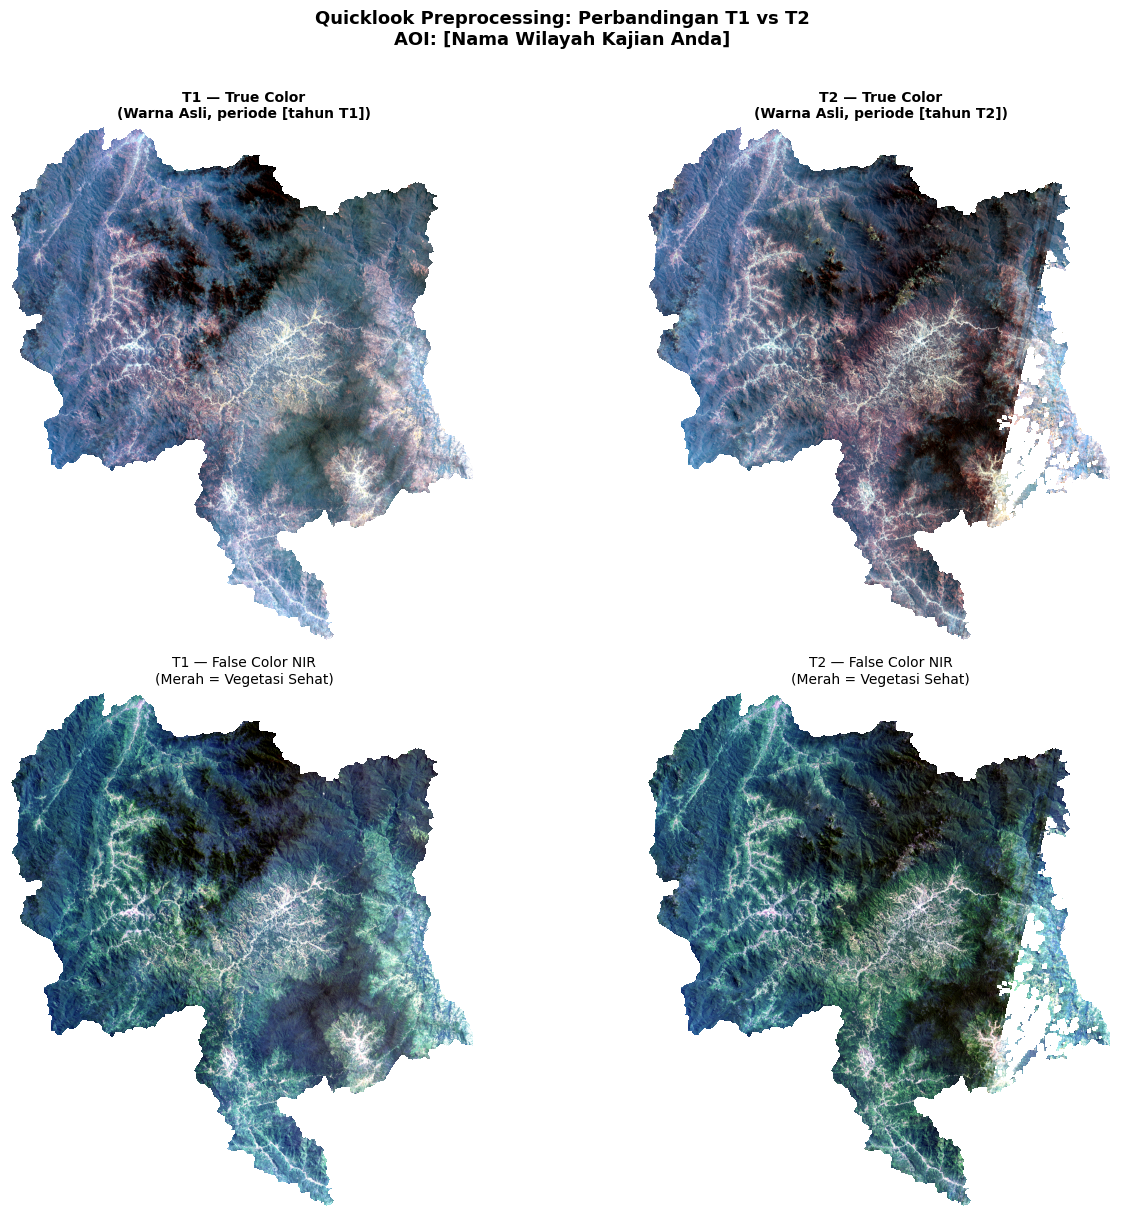

In [12]:
# ============================================================
# CELL 4 — Visualisasi Quicklook T1 vs T2 (4 Panel)
# ============================================================

# Buka T1 juga untuk perbandingan
with rasterio.open(PATH_T1) as src:
    data_T1 = src.read()

band_red_T1  = data_T1[2]
band_green_T1 = data_T1[1]
band_blue_T1  = data_T1[0]
band_nir_T1   = data_T1[3]
band_ndvi_T1  = data_T1[6]

rgb_T1 = np.dstack([normalisasi_band(band_red_T1),
                    normalisasi_band(band_green_T1),
                    normalisasi_band(band_blue_T1)])

fcc_T1 = np.dstack([normalisasi_band(band_nir_T1),
                    normalisasi_band(band_red_T1),
                    normalisasi_band(band_green_T1)])

# Buat figure 4-panel: T1 True Color | T2 True Color
#                      T1 False Color | T2 False Color
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Quicklook Preprocessing: Perbandingan T1 vs T2\n" +
             "AOI: [Nama Wilayah Kajian Anda]",  # ⚠ Ganti nama AOI
             fontsize=13, fontweight="bold", y=1.01)

# Panel kiri atas: T1 True Color
axes[0,0].imshow(rgb_T1)
axes[0,0].set_title(f"T1 — True Color\n(Warna Asli, periode [tahun T1])",  # ⚠ Ganti
                   fontsize=10, fontweight="bold")
axes[0,0].axis("off")

# Panel kanan atas: T2 True Color
axes[0,1].imshow(rgb_T2)
axes[0,1].set_title(f"T2 — True Color\n(Warna Asli, periode [tahun T2])",
                   fontsize=10, fontweight="bold")
axes[0,1].axis("off")

# Panel kiri bawah: T1 False Color
axes[1,0].imshow(fcc_T1)
axes[1,0].set_title("T1 — False Color NIR\n(Merah = Vegetasi Sehat)",
                   fontsize=10)
axes[1,0].axis("off")

# Panel kanan bawah: T2 False Color
axes[1,1].imshow(fcc_T2)
axes[1,1].set_title("T2 — False Color NIR\n(Merah = Vegetasi Sehat)",
                   fontsize=10)
axes[1,1].axis("off")

plt.tight_layout()

# Simpan quicklook ke Drive
path_quicklook = f"{DRIVE_BASE}/outputs/maps/quicklook_T1vsT2.png"
os.makedirs(os.path.dirname(path_quicklook), exist_ok=True)
plt.savefig(path_quicklook, dpi=150, bbox_inches="tight")
print(f"✅ Quicklook disimpan: {path_quicklook}")
plt.show()



📊 Rata-rata NDVI T1: 0.9314
📊 Rata-rata NDVI T2: 0.9158
📊 Perubahan NDVI (delta): -0.0156
➡ NDVI relatif stabil — perubahan minimal dalam periode ini


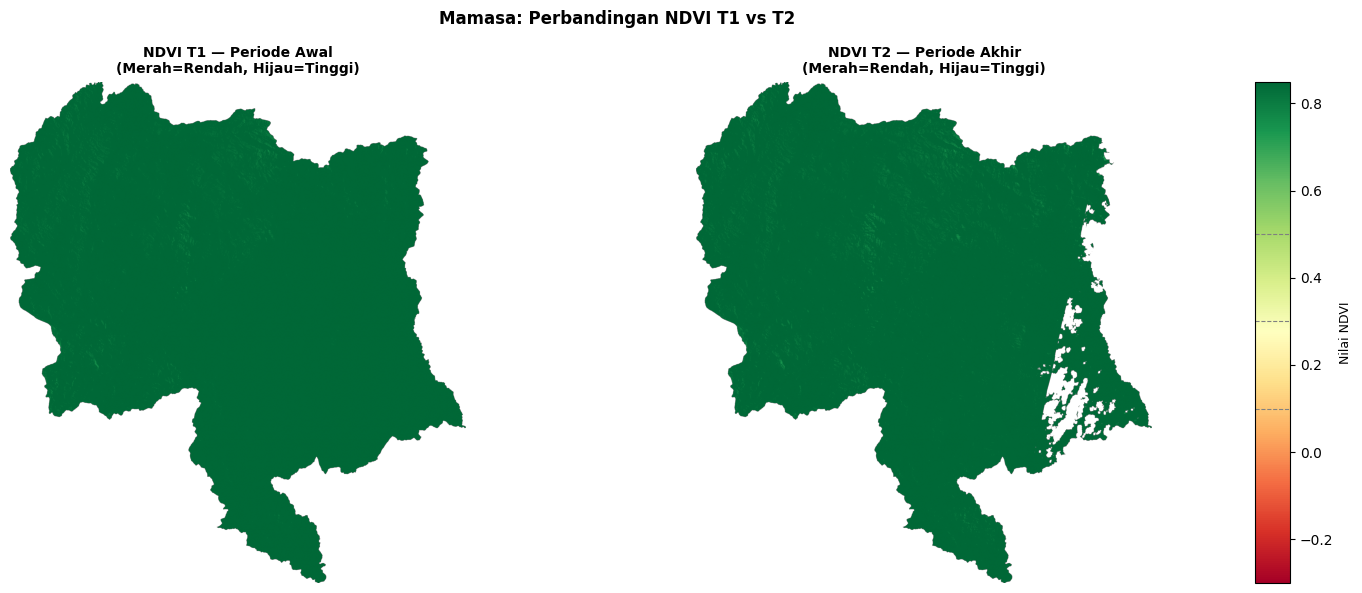

In [14]:
# ============================================================
# CELL 5 — Visualisasi Peta NDVI dengan Colorbar Profesional
# ============================================================

# Buat figure untuk perbandingan NDVI T1 vs T2
fig, (ax1, ax2, cax) = plt.subplots(1, 3,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1, 1, 0.05]})

# Normalisasi NDVI: rentang -0.2 sampai 0.8
ndvi_norm = Normalize(vmin=-0.3, vmax=0.85)
cmap_ndvi = plt.cm.RdYlGn  # merah-kuning-hijau, cocok untuk NDVI

# NDVI T1
ndvi_T1_masked = np.ma.masked_where(band_ndvi_T1 <= -9998, band_ndvi_T1)
im1 = ax1.imshow(ndvi_T1_masked, cmap=cmap_ndvi, norm=ndvi_norm)
ax1.set_title("NDVI T1 — Periode Awal\n(Merah=Rendah, Hijau=Tinggi)",
             fontsize=10, fontweight="bold")
ax1.axis("off")

# NDVI T2
ndvi_T2_masked = np.ma.masked_where(band_ndvi <= -9998, band_ndvi)
im2 = ax2.imshow(ndvi_T2_masked, cmap=cmap_ndvi, norm=ndvi_norm)
ax2.set_title("NDVI T2 — Periode Akhir\n(Merah=Rendah, Hijau=Tinggi)",
             fontsize=10, fontweight="bold")
ax2.axis("off")

# Colorbar
plt.colorbar(im1, cax=cax)
cax.set_ylabel("Nilai NDVI", fontsize=9)

# Tambahkan label interpretasi di colorbar
cax.axhline(y=0.1, color="gray", linewidth=0.8, linestyle="--")
cax.axhline(y=0.3, color="gray", linewidth=0.8, linestyle="--")
cax.axhline(y=0.5, color="gray", linewidth=0.8, linestyle="--")

fig.suptitle("Mamasa: Perbandingan NDVI T1 vs T2",
             fontsize=12, fontweight="bold")
plt.tight_layout()

# Hitung rata-rata NDVI untuk anotasi
mean_ndvi_T1 = band_ndvi_T1[band_ndvi_T1 > -9998].mean()
mean_ndvi_T2 = band_ndvi[band_ndvi > -9998].mean()
delta_ndvi   = mean_ndvi_T2 - mean_ndvi_T1

print(f"\n📊 Rata-rata NDVI T1: {mean_ndvi_T1:.4f}")
print(f"📊 Rata-rata NDVI T2: {mean_ndvi_T2:.4f}")
print(f"📊 Perubahan NDVI (delta): {delta_ndvi:+.4f}")
if delta_ndvi < -0.05:
    print("⬇ NDVI menurun — kemungkinan degradasi vegetasi atau perluasan lahan terbuka")
elif delta_ndvi > 0.05:
    print("⬆ NDVI meningkat — kemungkinan peningkatan vegetasi atau revegetasi")
else:
    print("➡ NDVI relatif stabil — perubahan minimal dalam periode ini")

plt.savefig(f"{DRIVE_BASE}/outputs/maps/ndvi_T1vsT2.png", dpi=150, bbox_inches="tight")
plt.show()
